In [ ]:
# =====================================
# IMPORTS & CONFIGURATION
# =====================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# =====================================
# DATA LOADING
# =====================================
df = pd.read_csv(
    "D:/Projects/fraud_detection_platform/data/raw/fraud_data.csv",
    dtype={
        "step": "int32",
        "amount": "float32",
        "isFraud": "int8",
        "isFlaggedFraud": "int8"
    }
)
print("\nFirst 5 Rows")
print(df.head())


First 5 Rows
   step      type        amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.639648  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.280029  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.000000  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.000000   C840083671          181.0            0.00   
4     1   PAYMENT  11668.139648  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


In [ ]:
# =====================================
# DATASET OVERVIEW
# =====================================
# DATASET OVERVIEW
# #Information of data
df.info()
#description about data
df.describe()
# Shape of dataset
print("\nDataset Shape:\n",df.shape)
# Datatypes of columns
print("\nData Types:\n",df.dtypes)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int32  
 1   type            object 
 2   amount          float32
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int8   
 10  isFlaggedFraud  int8   
dtypes: float32(1), float64(4), int32(1), int8(2), object(3)
memory usage: 400.5+ MB

Dataset Shape:
 (6362620, 11)

Data Types:
 step                int32
type               object
amount            float32
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud              int8
isFlaggedFraud       int8
dtype: object


In [5]:
print(df.memory_usage(deep=True).sum() / 1024**2, "MB")

1464.7011966705322 MB


In [ ]:
# =====================================
# DATA QUALITY CHECKS
# =====================================
# Check null values
print("\nNull Values:\n",df.isnull().sum())
#Check Duplicate values
print("Check for Duplicated records: ",df.duplicated().sum())


Null Values:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64
Check for Duplicated records:  0



Fraud Distribution
 isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud Percentage is
 isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


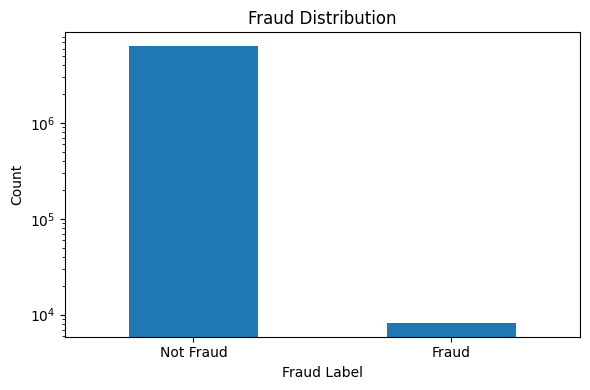

In [ ]:
# =====================================
# TARGET VARIABLE ANALYSIS
# =====================================
#check fraud distribution
fraud_counts=df['isFraud'].value_counts()
print("\nFraud Distribution\n",fraud_counts)
#Checking Fraud percentage
print("\nFraud Percentage is\n",df['isFraud'].value_counts(normalize=True)*100)
# fraud vs non-fraud plot
plt.figure(figsize=(6,4))
fraud_counts.plot(kind='bar')
plt.yscale("log")
plt.title("Fraud Distribution")
plt.xlabel("Fraud Label")
plt.ylabel("Count")
plt.xticks([0,1], ['Not Fraud', 'Fraud'], rotation=0)
plt.tight_layout()
plt.show()

isFraud         0     1
type                   
CASH_IN   1399284     0
CASH_OUT  2233384  4116
DEBIT       41432     0
PAYMENT   2151495     0
TRANSFER   528812  4097

 
 count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64


      oldbalanceOrg  newbalanceOrig   amount
2            181.0             0.0    181.0
3            181.0             0.0    181.0
251         2806.0             0.0   2806.0
252         2806.0             0.0   2806.0
680        20128.0             0.0  20128.0


              count          mean        std   min            25%  \
isFraud                                                            
0        6354407.0  1.781970e+05   596237.0  0.01   13368.395020   
1           8213.0  1.467967e+06  2404253.0  0.00  127091.328125   

                  50%           75%         max  
isFraud                       

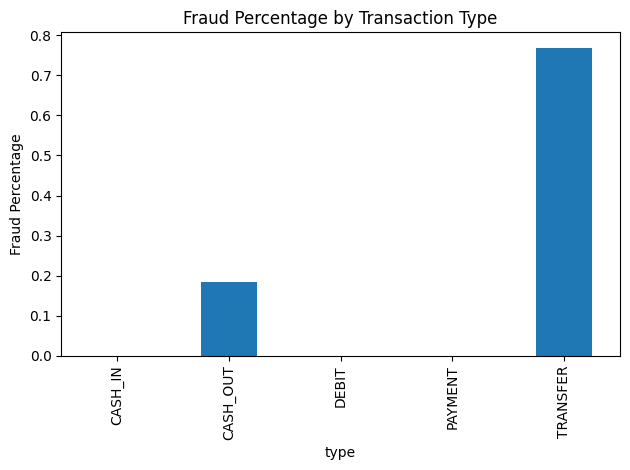

In [ ]:
# =====================================
# TRANSACTION TYPE ANALYSIS
# =====================================
# Analyze transaction types against fraud occurrence
print(pd.crosstab(df['type'], df['isFraud']))

# Summary statistics for transaction amount
print("\n \n",df["amount"].describe())

# Inspect sample fraudulent transactions
print("\n\n",
    df[df["isFraud"] == 1][
        ["oldbalanceOrg", "newbalanceOrig", "amount"]
    ].head()
)

# Compare amount distribution for fraud vs non-fraud transactions
print("\n\n",df.groupby("isFraud")["amount"].describe())

# Calculate fraud percentage for each transaction type
fraud_by_type = df.groupby("type")["isFraud"].mean() * 100
print(fraud_by_type)

# Visualize fraud percentage across transaction types
fraud_by_type.plot(kind='bar')
plt.title("Fraud Percentage by Transaction Type")
plt.ylabel("Fraud Percentage")
plt.tight_layout()
plt.show()

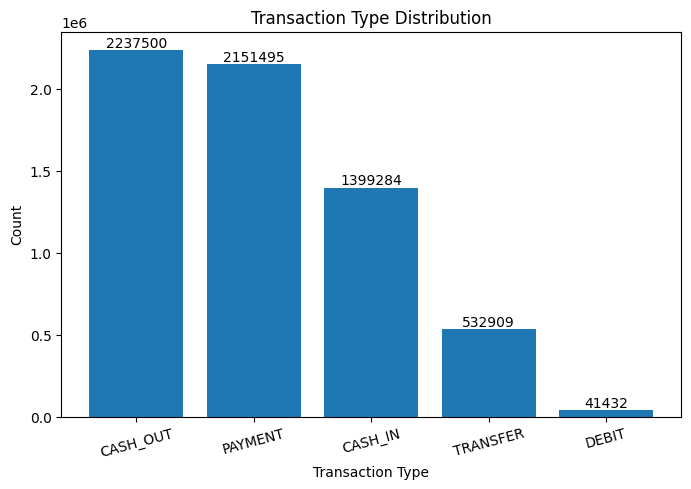

In [9]:
# Count transaction types
type_counts = df['type'].value_counts()

# Plot
plt.figure(figsize=(8,5))

bars = plt.bar(type_counts.index, type_counts.values)

# Title and labels
plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xticks(rotation=15)

plt.show()

isFraud           1.000000
amount            0.076688
isFlaggedFraud    0.044109
step              0.031578
oldbalanceOrg     0.010154
newbalanceDest    0.000535
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148
Name: isFraud, dtype: float64


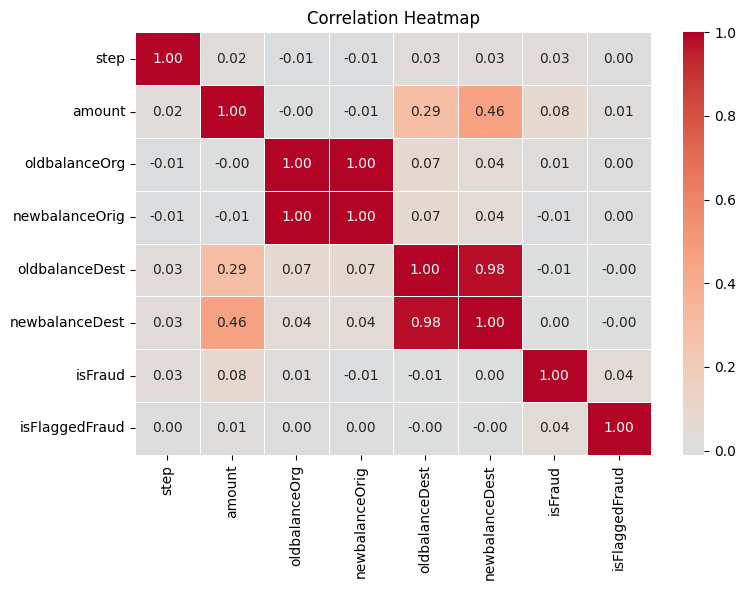

In [ ]:
# =====================================
# FEATURE RELATIONSHIP ANALYSIS
# =====================================
# Select only numerical columns
numeric_cols = df.select_dtypes(include=['number'])

# Compute correlation matrix
corr = numeric_cols.corr()

# Correlation with target variable
print(corr["isFraud"].sort_values(ascending=False))

# Visualize correlations using a heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f",center=0,linewidths=0.5)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()